In [2]:
import pickle
from sklearn.base import BaseEstimator, TransformerMixin
from gensim.corpora.dictionary import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pandas as pd
import numpy as np
import re

In [3]:
def convertir_a_lista(linea):
    texto = ''
    for a in linea.split():
        palabra = ''.join(re.findall(r'[a-z]',a))
        texto += palabra + ' '

    return texto.split()

class SklearnLDA(BaseEstimator, TransformerMixin):
    def __init__(self, metric='coherence', num_topics=10, alpha='symmetric', eta='symmetric', passes=10, chunksize=200,random_state=None):
        self.metric=metric
        self.num_topics = num_topics
        self.alpha = alpha
        self.eta = eta
        self.passes = passes
        self.chunksize = chunksize
        self.random_state = random_state
        self.model = None
        self.dictionary = None
    
    def fit(self, X, y=None):
        self.dictionary = Dictionary(X)
        corpus = [self.dictionary.doc2bow(text) for text in X]
        
        self.model = LdaModel(
            corpus=corpus,
            id2word=self.dictionary,
            num_topics=self.num_topics,
            alpha=self.alpha,
            eta=self.eta,
            passes=self.passes,
            chunksize=self.chunksize,
            random_state=self.random_state
        )
        return self
    
    def transform(self, X):
        corpus = [self.dictionary.doc2bow(text) for text in X]
        return np.array([
            [topic_prob for _, topic_prob in self.model.get_document_topics(doc, minimum_probability=0.0)]
            for doc in corpus
        ])
    
    def get_metric(self, X):
        if self.metric=='coherence':
            coherence_model = CoherenceModel(model=self.model, texts=X, dictionary=self.dictionary, coherence='c_v')
            return coherence_model.get_coherence()
            
    
    def score(self, X, y=None):
        return self.get_metric(X)

df = pd.read_excel('nueva_base.xlsx') 
Documentos = []

for i in range(0, 10217+1):
    Documentos.append(convertir_a_lista(df.tokens[i]))

# DAVIES (2 Topics)

In [10]:
with open('lda_davies_V4.pkl', 'rb') as file:
    d_davies = pickle.load(file)

In [11]:
d_davies

SklearnLDA(alpha='auto', metric='davies', num_topics=2, passes=20,
           random_state=42)

In [18]:
df_davies = pd.read_csv('/Users/fiorella/Downloads/df_final_davis_2.csv',index_col=0)
df_davies

,disease,date,title,domain,Topico,FV,sentiment,category
0,ANTRAX,2010-08-29 00:00:00,Alarma en camal de Chincha por ántrax,diariocorreo,1,"[0.2764996588230133, 0.7235003709793091]",3,zoonotic
1,ANTRAX,2012-01-12 00:00:00,Detectan dos casos de ántrax en Sama Inclán,diariocorreo,0,"[0.695146918296814, 0.3048531115055084]",1,zoonotic
2,ANTRAX,2014-02-27 00:00:00,Tacna: Senasa descarta que ántrax hallada en o...,rpp,1,"[0.35866764187812805, 0.6413323879241943]",3,zoonotic
3,ANTRAX,2014-02-26 00:00:00,Senasa vacuna a ovinos y caprinos en Poquera p...,diariocorreo,1,"[0.25730204582214355, 0.7426979541778564]",3,zoonotic
4,ANTRAX,2014-02-25 00:00:00,Confirman la presencia de ántrax en una oveja,elcomercio,1,"[0.29399728775024414, 0.7060026526451111]",3,zoonotic
...,...,...,...,...,...,...,...,...
10213,ZIKA,2024-04-28 00:00:00,Lucha contra el dengue en Piura: Minsa y Dires...,andina,1,"[0.2198076844215393, 0.7801923155784607]",3,metaxenic
10214,ZIKA,2024-05-08 00:00:00,Minsa incorpora ficha técnica del preparado fa...,andina,1,"[0.10989721119403839, 0.8901028037071228]",3,metaxenic
10215,ZIKA,2024-05-27 00:00:00,Aumentan a quince los casos de Guillain Barré ...,diariocorreo,0,"[0.5528261065483093, 0.4471738934516907]",3,metaxenic
10216,ZIKA,2024-07-09 00:00:00,Piura: De seis piuranos solo uno recibe agua d...,noticiaspiura30,1,"[0.2754262089729309, 0.7245738506317139]",3,metaxenic


# COHERENCE (22 Topics)

In [4]:
d_coherence =  SklearnLDA(
    metric='coherence',
    num_topics=22,       
    alpha='auto',  
    eta='symmetric',         
    passes=10,           # Número de pases (iteraciones) sobre los datos
    chunksize=200,       # Tamaño de los fragmentos procesados
    random_state=42      
)

d_coherence.fit(Documentos)

SklearnLDA(alpha='auto', num_topics=22, random_state=42)

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from netgraph import Graph

topic_term_matrix = d_coherence.model.get_topics()
correlation_matrix = topic_term_matrix.dot(topic_term_matrix.T)
np.fill_diagonal(correlation_matrix, 0)

In [7]:
correlation_matrix *= 100
correlation_matrix

array([[0.        , 0.11428054, 0.04430761, 0.14503431, 0.04453158,
        0.01106063, 0.08374594, 0.00159515, 0.11671709, 0.17573261,
        0.05436605, 0.03412009, 0.00190324, 0.07567802, 0.05904536,
        0.06765834, 0.05347059, 0.10019726, 0.05885759, 0.02355277,
        0.10858292, 0.05712197],
       [0.11428054, 0.        , 0.02031091, 0.1172646 , 0.05245708,
        0.00980373, 0.46419924, 0.00129426, 0.12308276, 0.13280635,
        0.07457376, 0.09697469, 0.0019108 , 0.16969405, 0.22318552,
        0.12880328, 0.04419402, 0.28919742, 0.04978988, 0.02529372,
        0.18433478, 0.05659047],
       [0.04430761, 0.02031091, 0.        , 0.00234846, 0.00165983,
        0.00902935, 0.00537935, 0.0014182 , 0.09402875, 0.0141717 ,
        0.00204054, 0.0047177 , 0.00198551, 0.00114949, 0.09512147,
        0.01024069, 0.1065862 , 0.06658826, 0.00421206, 0.01092566,
        0.04764692, 0.0032148 ],
       [0.14503431, 0.1172646 , 0.00234846, 0.        , 0.01753853,
        0.0109576

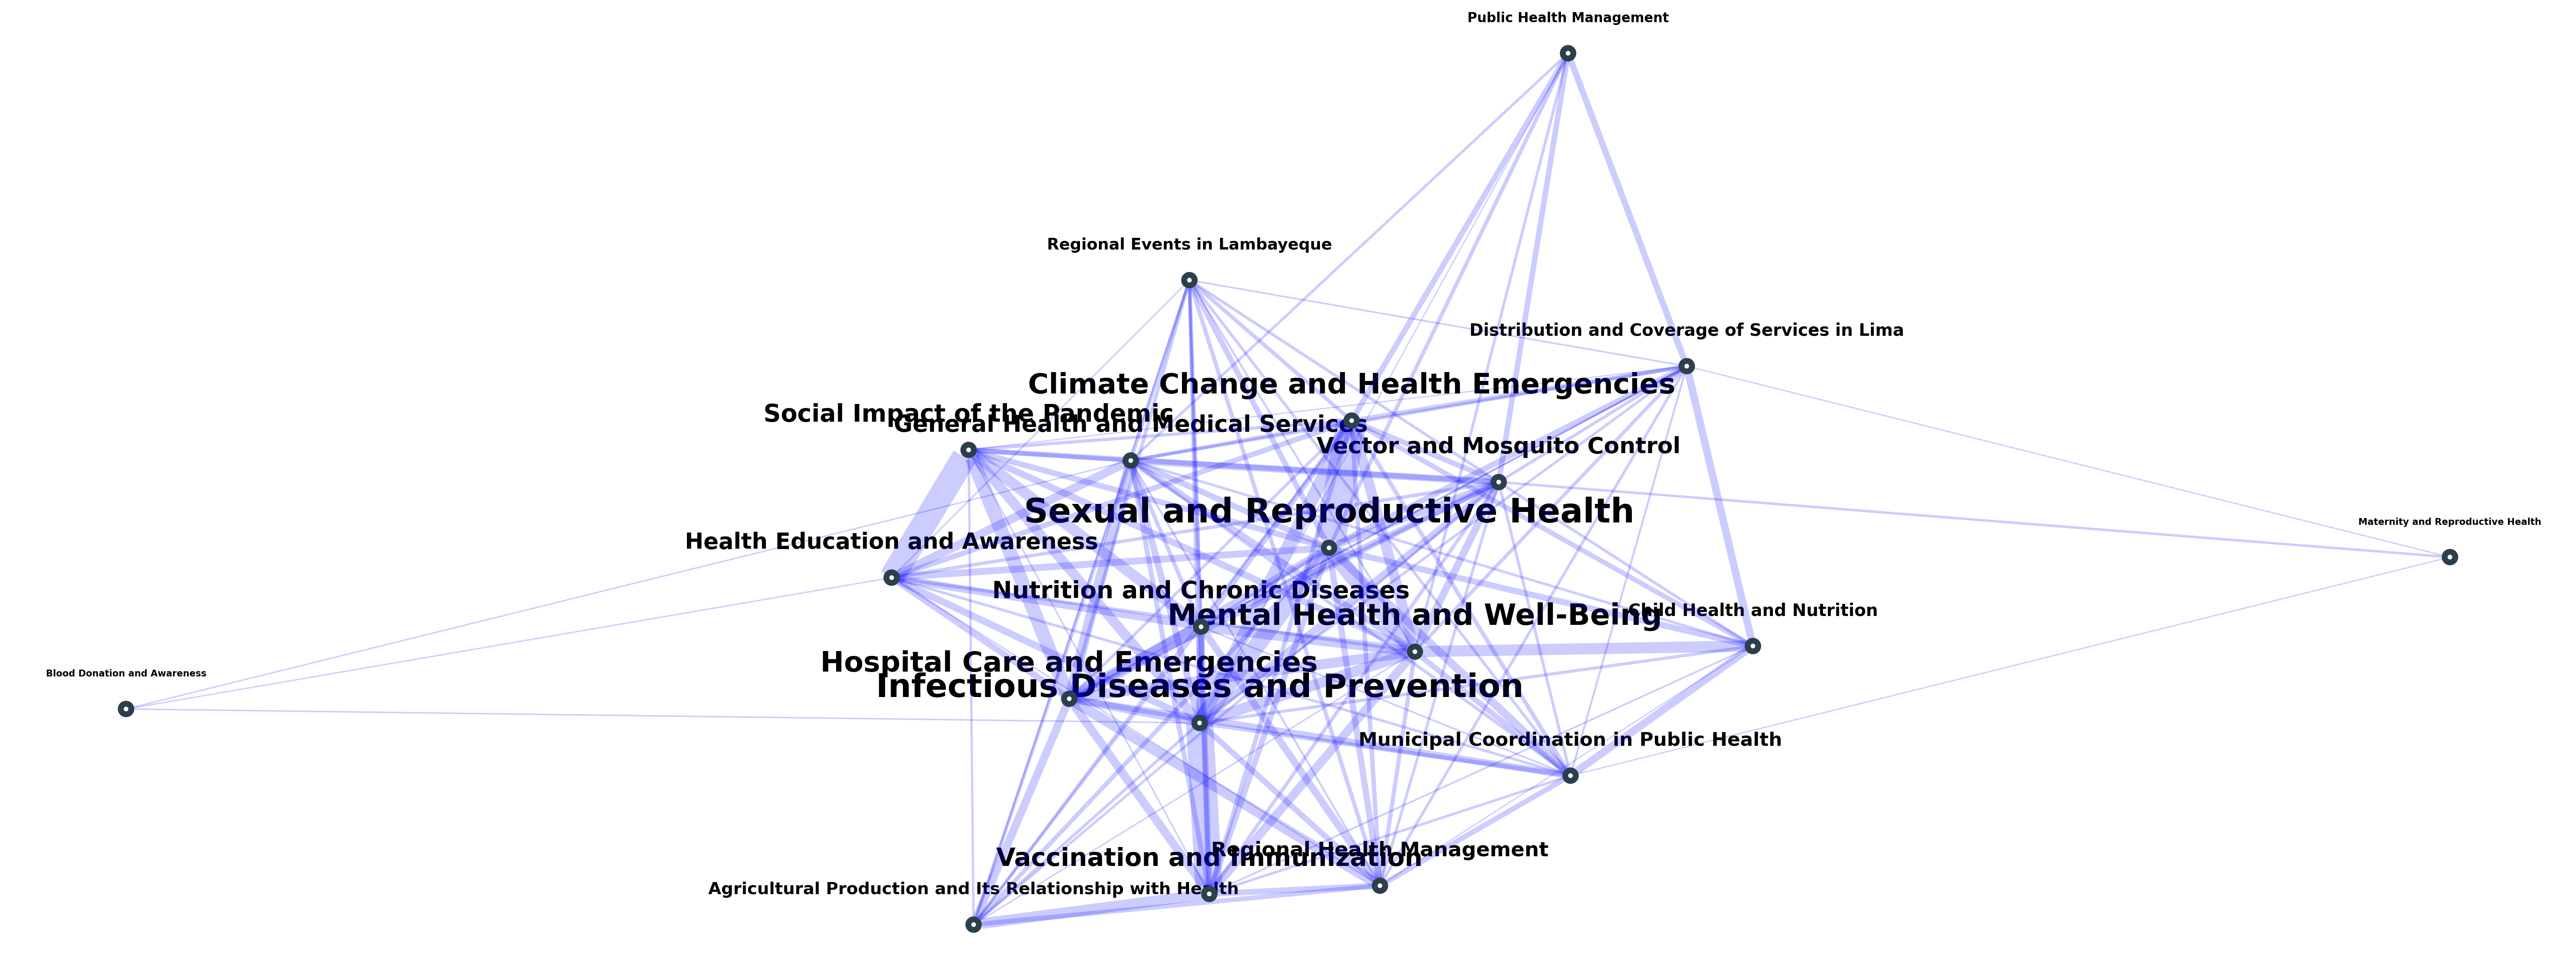

In [19]:
G = nx.Graph()
n_topics = 22
node_labels = {i: l for i,l in enumerate([
    "General Health and Medical Services",
    "Infectious Diseases and Prevention",
    "Public Health Management",
    "Health Education and Awareness",
    "Child Health and Nutrition",
    "Maternity and Reproductive Health",
    "Vaccination and Immunization",
    "Scientific Research in Health",
    "Vector and Mosquito Control",
    "Hospital Care and Emergencies",
    "Municipal Coordination in Public Health",
    "Regional Health Management",
    "Zoonotic Diseases and Animal Health",
    "Social Impact of the Pandemic",
    "Climate Change and Health Emergencies",
    "Nutrition and Chronic Diseases",
    "Distribution and Coverage of Services in Lima",
    "Sexual and Reproductive Health",
    "Agricultural Production and Its Relationship with Health",
    "Blood Donation and Awareness",
    "Mental Health and Well-Being",
    "Regional Events in Lambayeque"
])}
for i in range(len(correlation_matrix)):
    for j in range(i + 1, len(correlation_matrix)):
        weight = correlation_matrix[i, j]
        if weight >= 0.02:
            G.add_edge(i, j, weight=weight)
        
pos = nx.spring_layout(G, seed=41,k=0.1)
weights = nx.get_edge_attributes(G, 'weight')
edge_widths = {edge: weight * 5 for edge, weight in weights.items()} 

node_degrees = dict(G.degree(weight='weight'))  # Degree of each node (weighted)
max_degree = max(node_degrees.values())  # Max degree for normalization
font_sizes = {node: 15 + (45 * (degree / max_degree)) for node, degree in node_degrees.items()}


fig, ax = plt.subplots(figsize=(64, 32))


    
graph = Graph(
    G,
    node_layout=pos,
    edge_width=edge_widths,
    edge_alpha=0.2,
    edge_bundling=True,  # Enable edge bundling for better clarity
    edge_color='blue',   # Optional: Change edge color to blue
    node_size=0.7,        # Adjust node size
    ax=ax,
)

for node, (x, y) in pos.items():
    plt.text(
        x,
        y + 0.03,
        node_labels[node],
        fontsize=font_sizes[node],  # Scale font size
        ha='center',
        va='center',
        weight='bold',
        zorder=5,  # Ensure labels appear on top of edges
    )

plt.tight_layout()
plt.show()